In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

perfil_compradores = r"C:\MBA_DC_13\mba_ia_unifor_13\praticas\projeto_final\projeto_09\data\projeto_09_compradores_perfil.csv"

preços_bairro = r"C:\MBA_DC_13\mba_ia_unifor_13\praticas\projeto_final\projeto_09\data\projeto_09_historico_precos_bairro.csv"

mercado_imobiliario = r"C:\MBA_DC_13\mba_ia_unifor_13\praticas\projeto_final\projeto_09\data\projeto_09_mercado_imobiliario.csv"



In [7]:
df_compradores = pd.read_csv(perfil_compradores, delimiter=',')

print('\n Exibindo perfil de compradores\n')
print(df_compradores.head())


 Exibindo perfil de compradores

  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep  
0                          1                         0    0  
1                          1                         0    0  
2                          1                         0    0  
3                          2                         0    0  
4                          1                         0    1  


In [8]:

df_preços_bairros = pd.read_csv(preços_bairro, delimiter=',')

print('\n Exibindo preços dos bairros\n')
print(df_preços_bairros.head())




 Exibindo preços dos bairros

     bairro   ano  trimestre  preco_m2_referencia  numero_transacoes  \
0  Meireles  2022          1             11983.07                 75   
1  Meireles  2022          2             12482.67                 30   
2  Meireles  2022          3             11604.47                 22   
3  Meireles  2022          4             11762.33                 60   
4  Meireles  2023          1             12168.42                 13   

   variacao_trimestral_pct  
0                     -1.9  
1                      2.2  
2                      0.4  
3                      2.6  
4                      1.5  


In [9]:
df_mercado_imobiliario = pd.read_csv(mercado_imobiliario, delimiter=',')

# substituindo nulos por 0 e tranformando campo em inteiro
df_mercado_imobiliario["dias_no_mercado"] = (df_mercado_imobiliario["dias_no_mercado"].fillna(0).astype(int))

df_mercado_imobiliario["CNPJ OK"] = df_mercado_imobiliario["comprador_cnpj"]

# verifica se nao é nulo, caso nao seja retorna SIM
df_mercado_imobiliario["comprador_cnpj"] = df_mercado_imobiliario["comprador_cnpj"].notna().map({True: "sim", False: "nao"})

print('\n Exibindo mercado imobiliario\n')
print(df_mercado_imobiliario.head())




 Exibindo mercado imobiliario

  transacao_id  imovel_id     bairro  tipo_imovel  area_m2  quartos condicao  \
0     TX-00001  IMO-00001     Centro  Apartamento       92        3    Usado   
1     TX-00002  IMO-00002  Messejana    Cobertura      215        3    Usado   
2     TX-00003  IMO-00003  Parangaba  Apartamento       62        3     Novo   
3     TX-00004  IMO-00004  Maracanaú  Apartamento       53        2    Usado   
4     TX-00005  IMO-00005  Maraponga  Apartamento       70        3     Novo   

   preco_total  preco_m2 comprador_id comprador_cnpj forma_pagamento  \
0    418313.16   4546.88    CPF-02925            nao         À vista   
1    736733.31   3426.67    CPF-02069            nao   Financiamento   
2    295173.19   4760.86    CPF-02157            nao   Financiamento   
3    153461.20   2895.49    CPF-03428            nao   Financiamento   
4    331702.68   4738.61    CPF-00673            nao         À vista   

   ano_transacao  mes_transacao  dias_no_mercado CNPJ 

In [10]:
df_consolidado = pd.merge(df_compradores,df_mercado_imobiliario, on='comprador_id', how = 'inner')

print(df_consolidado.head())


  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep transacao_id  \
0                          1                         0    0     TX-01622   
1                          1                         0    0     TX-02830   
2                          1                         0    0     TX-00129   
3                          2                         0    0     TX-01609   
4                          1                         0    1     TX-03457   

   imovel_id  ... quartos condicao  preco_total  preco_m2 comprador_cnpj  \
0  IMO-01622  ..

In [11]:
#agrupa bairro-preço e traz a media de preço por bairro
media_por_bairro = df_preços_bairros.groupby("bairro")["preco_m2_referencia"].mean().reset_index()
#transforma preço para float
media_por_bairro["preco_m2_referencia"] = media_por_bairro["preco_m2_referencia"].astype(float)
#cruza base de compradores com a media de preço por bairro
df_master = pd.merge(df_consolidado, media_por_bairro, on="bairro", how="left")

print("Colunas:", df_master.columns)
print(df_master.head())

Colunas: Index(['comprador_id', 'renda_mensal_declarada', 'idade', 'estado_civil',
       'profissao', 'numero_imoveis_adquiridos', 'possui_restricao_credito',
       'pep', 'transacao_id', 'imovel_id', 'bairro', 'tipo_imovel', 'area_m2',
       'quartos', 'condicao', 'preco_total', 'preco_m2', 'comprador_cnpj',
       'forma_pagamento', 'ano_transacao', 'mes_transacao', 'dias_no_mercado',
       'CNPJ OK', 'preco_m2_referencia'],
      dtype='str')
  comprador_id  renda_mensal_declarada  idade estado_civil    profissao  \
0    CPF-03931                 8015.56     46       Casado     Advogado   
1    CPF-07445                 4047.78     55   Divorciado     Servidor   
2    CPF-01663                 8790.44     55       Casado   Empresário   
3    CPF-04479                 8191.80     61       Casado  Comerciante   
4    CPF-02381                 9396.28     45       Casado       Médico   

   numero_imoveis_adquiridos  possui_restricao_credito  pep transacao_id  \
0                  

In [12]:
df_master['variação'] = (df_master['preco_m2'] / df_master['preco_m2_referencia']) - 1

df_master['é suspeito?'] = np.where(df_master['variação'] >= 0.40,'SIM','NÃO')

df_suspeitos_sobrepreco = df_master[['transacao_id', 'comprador_id', 'bairro', 'variação','é suspeito?','profissao']]

print(df_suspeitos_sobrepreco.head(10))

print("1. Transações com Sobrepreço:")

  transacao_id comprador_id     bairro  variação é suspeito?    profissao
0     TX-01622    CPF-03931  Maraponga -0.098722         NÃO     Advogado
1     TX-02830    CPF-07445     Centro  0.063916         NÃO     Servidor
2     TX-00129    CPF-01663    Montese -0.063420         NÃO   Empresário
3     TX-01609    CPF-04479   Meireles  0.024505         NÃO  Comerciante
4     TX-03457    CPF-02381     Centro  0.485268         SIM       Médico
5     TX-01962    CPF-04945  Messejana  0.067515         NÃO     Autônomo
6     TX-02242    CPF-00561    Aldeota  0.136587         NÃO     Autônomo
7     TX-00421    CPF-02687    Benfica  0.221048         NÃO  Comerciante
8     TX-03155    CPF-00378    Eusébio  0.029737         NÃO       Médico
9     TX-00324    CPF-00385  Maraponga -0.088431         NÃO     Servidor
1. Transações com Sobrepreço:


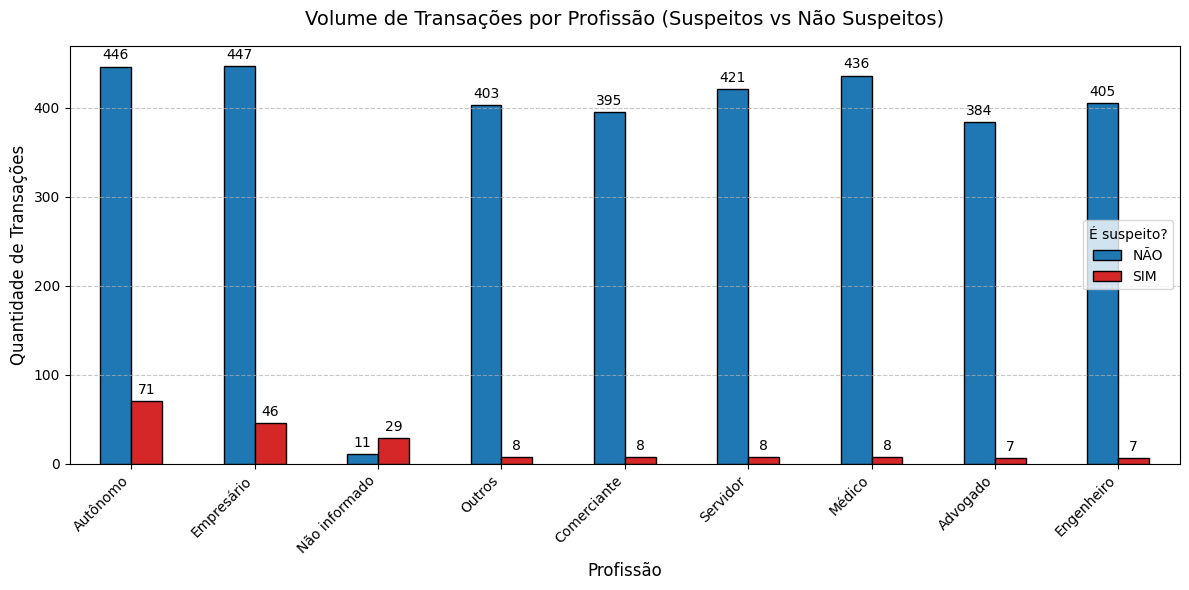

In [13]:
dados_grafico = pd.crosstab(df_master['profissao'], df_master['é suspeito?'])

# Ordena o DataFrame baseando-se na coluna 'SIM' do maior para o menor
dados_grafico = dados_grafico.sort_values(by='SIM', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
dados_grafico.plot(kind='bar', ax=ax, color=['#1f77b4', '#d62728'], edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Volume de Transações por Profissão (Suspeitos vs Não Suspeitos)', fontsize=14, pad=15)
plt.xlabel('Profissão', fontsize=12)
plt.ylabel('Quantidade de Transações', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='É suspeito?')
plt.tight_layout()

plt.show()


2. CPFs com Renda Incompatível:
     comprador_id  renda_mensal_declarada  preco_total compra_suspeita?
0       CPF-03931                 8015.56    110495.80              NÃO
1       CPF-07445                 4047.78    564654.29              NÃO
2       CPF-01663                 8790.44    527718.19              NÃO
3       CPF-04479                 8191.80    258916.93              NÃO
4       CPF-02381                 9396.28    514095.46              NÃO
...           ...                     ...          ...              ...
3535    CPF-03338                 8466.55    530745.12              NÃO
3536    CPF-01373                11316.16    509178.69              NÃO
3537    CPF-01373                11316.16    971796.61              NÃO
3538    CPF-04854                 8073.48    391405.86              NÃO
3539    CPF-04770                12266.98   1066524.47              NÃO

[3540 rows x 4 columns]
  SUSPEITO?  Soma de RENDA DECLARADA  Soma de preco_total  investimento/renda


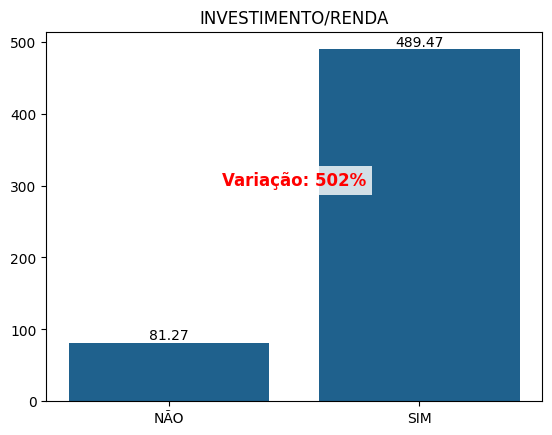

In [14]:


# suspeitos_renda = df_master[(df_master['preco_total'] >= 1000000) & (df_master['renda_mensal_declarada'] < 5000)]


df_master['compra_suspeita?'] = np.where((df_master['preco_total'] >= 1000000) & (df_master['renda_mensal_declarada'] < 5000), 'SIM', 'NÃO')


print("\n2. CPFs com Renda Incompatível:")
print(df_master[['comprador_id', 'renda_mensal_declarada', 'preco_total','compra_suspeita?']])

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

visao_suspeitos = df_master.groupby('compra_suspeita?').agg({'renda_mensal_declarada': 'sum','preco_total': 'sum'}).reset_index()

visao_suspeitos.columns = ['SUSPEITO?', 'Soma de RENDA DECLARADA', 'Soma de preco_total']

visao_suspeitos['investimento/renda'] = (visao_suspeitos['Soma de preco_total']/visao_suspeitos['Soma de RENDA DECLARADA'])

print(visao_suspeitos)

x = visao_suspeitos['SUSPEITO?']
y = visao_suspeitos['investimento/renda']

# 2. Plotagem com o azul petróleo (mesmo estilo do prompt anterior)
plt.bar(x, y, color='#1f618d')

# 3. Adicionar valores em cima das barras
for i, valor in enumerate(y):
    plt.text(i, valor, f'{valor:.2f}', ha='center', va='bottom')

# 4. Adicionar a variação de 502% entre as barras
# Posicionamos no centro (0.5) e numa altura média
plt.annotate('Variação: 502%', 
             xy=(0.5, 300), 
             ha='center', 
             fontsize=12, 
             fontweight='bold',
             color='red',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('INVESTIMENTO/RENDA')
plt.show()


In [15]:
df_master['maior_3_aquisicoes?'] = np.where(df_master['numero_imoveis_adquiridos'] >= 3, 'SIM', 'NÃO')

visao_profissao = df_master.groupby(['profissao', 'maior_3_aquisicoes?'])['comprador_id'].nunique().unstack(fill_value=0)

print(visao_profissao)

maior_3_aquisicoes?  NÃO  SIM
profissao                    
Advogado             323    0
Autônomo             351   10
Comerciante          331    0
Empresário           344    6
Engenheiro           334    0
Médico               363    0
Não informado          0    4
Outros               331    0
Servidor             334    0


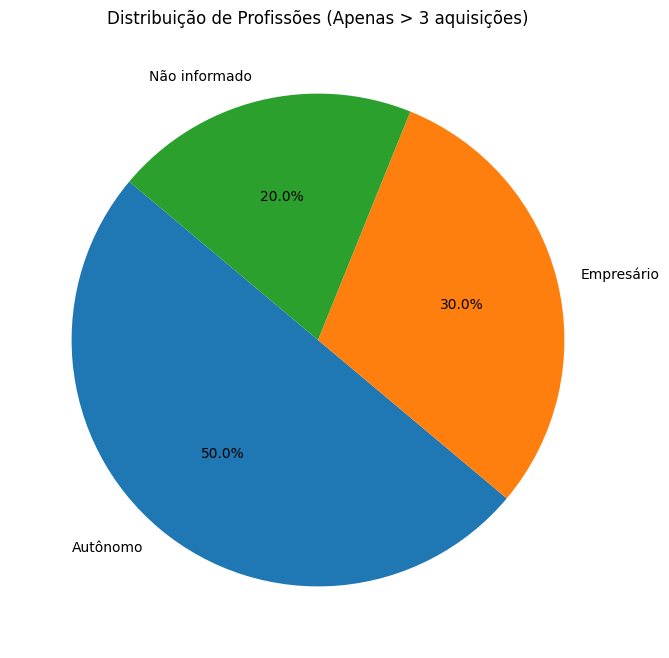

In [16]:
dados_sim = visao_profissao['SIM'][visao_profissao['SIM'] > 0]

plt.figure(figsize=(8, 8))
plt.pie(dados_sim, labels=dados_sim.index, autopct='%1.1f%%', startangle=140)

plt.title('Distribuição de Profissões (Apenas > 3 aquisições)')
plt.show()


Imóveis com várias transações:
   imovel_id  preco_total varias_transacoes
0  IMO-01622    110495.80               NAO
1  IMO-02830    564654.29               NAO
2  IMO-00129    527718.19               NAO
3  IMO-01609    258916.93               NAO
4  IMO-03457    514095.46               NAO

Imóveis revendidos com variação de preço:
   imovel_id  valor_minimo  valor_maximo  variacao_pct lucro_suspeito
0  IMO-00042     845693.31    1453005.07         71.81            SIM
1  IMO-00057    1032268.52    1563929.47         51.50            SIM
2  IMO-00174     634815.35    1100545.19         73.36            SIM
3  IMO-00408    1340043.73    2300753.57         71.69            SIM
4  IMO-00414    2364262.64    4169478.33         76.35            SIM

Imóveis com lucro acima de 50%:
    imovel_id  valor_minimo  valor_maximo  variacao_pct lucro_suspeito
6   IMO-00884    1017399.81    1824331.68         79.31            SIM
4   IMO-00414    2364262.64    4169478.33         76.35           

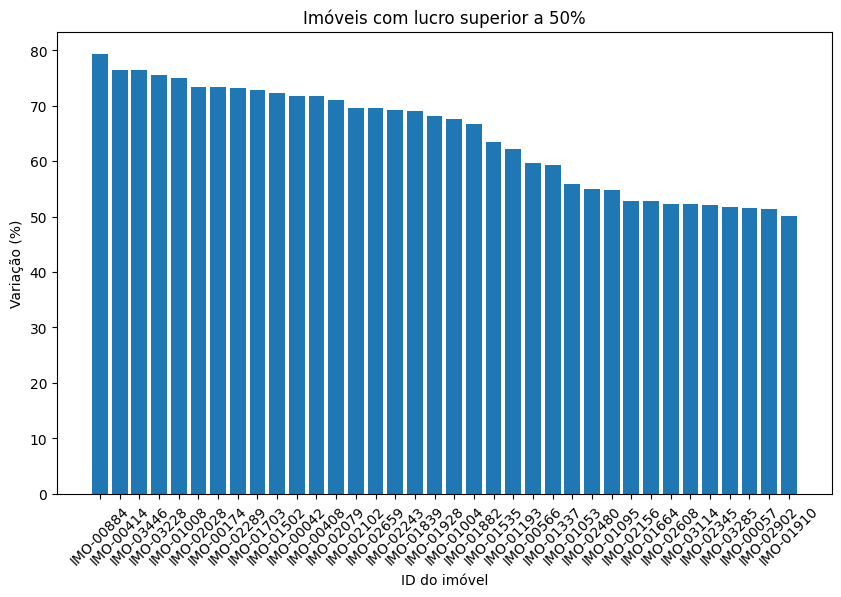

In [17]:
# contagem_imovel = df_master.groupby('imovel_id')['imovel_id'].transform('count')

# # 2. Se o imóvel aparecer mais que 2 vezes, recebe 'SIM', caso contrário 'NÃO'
# df_master['varias_transacoes'] = np.where(contagem_imovel > 2, 'SIM', 'NÃO')

# print(df_master[['varias_transacoes']])

df_master["varias_transacoes"] = df_master.duplicated(subset="imovel_id",keep=False)

df_master["varias_transacoes"] = df_master["varias_transacoes"].map({True: "SIM", False: "NAO"})

print("\nImóveis com várias transações:")
print(df_master[["imovel_id","preco_total","varias_transacoes"]].head())

df_varias = df_master[df_master["varias_transacoes"] == "SIM"]

df_revenda = df_varias.groupby("imovel_id")["preco_total"].agg(["min","max"]).reset_index()

df_revenda.rename(columns={"min":"valor_minimo","max":"valor_maximo"},inplace=True)

df_revenda["variacao_pct"] = ((df_revenda["valor_maximo"] - df_revenda["valor_minimo"])/df_revenda["valor_minimo"]) * 100

df_revenda["lucro_suspeito"] = np.where(df_revenda["variacao_pct"] > 50,"SIM","NAO")

print("\nImóveis revendidos com variação de preço:")
print(df_revenda.head())

suspeitos_flip = df_revenda[df_revenda["lucro_suspeito"] == "SIM"]
suspeitos_flip = suspeitos_flip.sort_values("variacao_pct",ascending=False)

print("\nImóveis com lucro acima de 50%:")
print(suspeitos_flip)

plt.figure(figsize=(10,6))

plt.bar(suspeitos_flip["imovel_id"],suspeitos_flip["variacao_pct"])

plt.title("Imóveis com lucro superior a 50%")
plt.xlabel("ID do imóvel")
plt.ylabel("Variação (%)")

plt.xticks(rotation=45)

plt.show()


Total de transações dos 5 principais CNPJs: 80
Média por CNPJ: 16.0
      CNPJ OK  quantidade_transacoes
2  CNPJ-08003                     20
3  CNPJ-08004                     16
0  CNPJ-08001                     15
4  CNPJ-08005                     15
1  CNPJ-08002                     14
Média de transações por CNPJ: 16.0


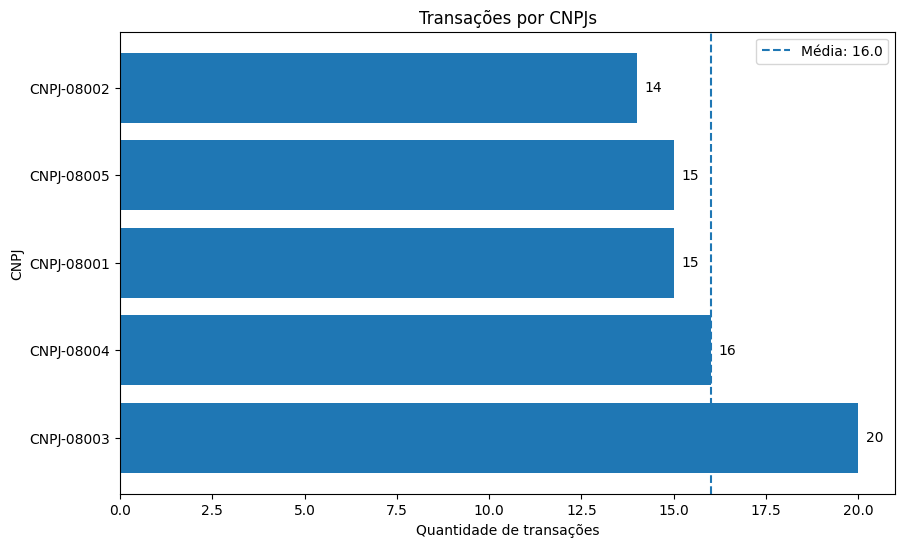

In [ ]:
# remover valores NaN da coluna CNPJ OK
df_cnpj = df_master[df_master["CNPJ OK"].notna()]

# agrupar pelo CNPJ e contar quantas transações cada um possui
cnpj_transacoes = df_cnpj.groupby("CNPJ OK")["transacao_id"].count().reset_index()

# renomear coluna para facilitar leitura
cnpj_transacoes.rename(
    columns={"transacao_id": "quantidade_transacoes"},
    inplace=True
)

# ordenar do maior para o menor
cnpj_transacoes = cnpj_transacoes.sort_values(by="quantidade_transacoes",ascending=False)

# pegar os 5 CNPJs com mais transações
top5_cnpj = cnpj_transacoes.head(5)

# calcular total e média
total_top5 = top5_cnpj["quantidade_transacoes"].sum()

top5_cnpj["quantidade_transacoes"] = top5_cnpj["quantidade_transacoes"].astype(int)

print("\nTotal de transações dos 5 principais CNPJs:", total_top5)
print("Média por CNPJ:", total_top5 / 5)

print(top5_cnpj)

# calcular média de transações por CNPJ
media_transacoes = cnpj_transacoes["quantidade_transacoes"].mean()

print("Média de transações por CNPJ:", round(media_transacoes,2))

plt.figure(figsize=(10,6))

bars = plt.barh(top5_cnpj["CNPJ OK"],top5_cnpj["quantidade_transacoes"])

plt.title("Transações por CNPJs")
plt.ylabel("CNPJ")
plt.xlabel("Quantidade de transações")

for bar in bars:

    largura = bar.get_width()

    plt.text(largura + 0.2,bar.get_y() + bar.get_height()/2,f'{int(largura)}',va='center')

plt.axvline(media_transacoes,linestyle='--',label=f"Média: {media_transacoes:.1f}")

plt.legend()

plt.show()

Index(['comprador_id', 'renda_mensal_declarada', 'idade', 'estado_civil',
       'profissao', 'numero_imoveis_adquiridos', 'possui_restricao_credito',
       'pep', 'transacao_id', 'imovel_id', 'bairro', 'tipo_imovel', 'area_m2',
       'quartos', 'condicao', 'preco_total', 'preco_m2', 'comprador_cnpj',
       'forma_pagamento', 'ano_transacao', 'mes_transacao', 'dias_no_mercado',
       'CNPJ OK', 'preco_m2_referencia', 'variação', 'é suspeito?',
       'compra_suspeita?', 'maior_3_aquisicoes?', 'varias_transacoes',
       'CNPJ_OK'],
      dtype='str')
  compra_suspeita?  transacao_id
0              SIM           168


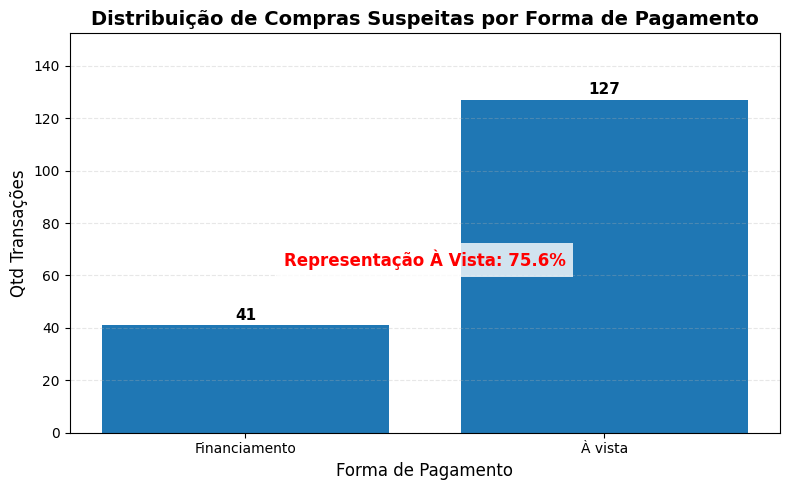

In [ ]:
print(df_master.columns)

df_compra_suspeita_fpgto = df_master[['transacao_id','forma_pagamento','compra_suspeita?']]

df_compra_suspeita_fpgto = df_compra_suspeita_fpgto[df_compra_suspeita_fpgto['compra_suspeita?'] == 'SIM']

df_compra_suspeita_fpgto = df_compra_suspeita_fpgto.groupby('compra_suspeita?')['transacao_id'].count().reset_index()

print(df_compra_suspeita_fpgto)

# 1. Filtramos apenas as compras suspeitas ('SIM')
df_suspeitas = df_master[df_master['compra_suspeita?'] == 'SIM']

# 2. Agrupamos por 'forma_pagamento' para contar as transações
df_plot = df_suspeitas.groupby('forma_pagamento')['transacao_id'].count().reset_index()

# --- CÁLCULO DA PORCENTAGEM ---
total_suspeitas = df_plot['transacao_id'].sum()
# Localiza o valor da contagem para 'À vista'
valor_a_vista = df_plot[df_plot['forma_pagamento'] == 'À vista']['transacao_id'].values[0]
porcentagem = (valor_a_vista / total_suspeitas) * 100
# ------------------------------

# 3. Criando o Gráfico de Barras
plt.figure(figsize=(8, 5))
barras = plt.bar(df_plot['forma_pagamento'], df_plot['transacao_id'], color='#1f77b4') # Azul mais sóbrio

# Adicionando os rótulos de dados (os números em cima de cada barra)
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. ADICIONANDO A VARIAÇÃO/PORCENTAGEM (Destaque Central)
# Posicionamos o texto no meio do gráfico (eixo x=0.5, eixo y=metade da maior barra)
plt.text(0.5, max(df_plot['transacao_id'])/2, f'Representação À Vista: {porcentagem:.1f}%', fontsize=12, color='red', fontweight='bold', ha='center',bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))

# Customização visual
plt.title('Distribuição de Compras Suspeitas por Forma de Pagamento', fontsize=14, fontweight='bold')
plt.xlabel('Forma de Pagamento', fontsize=12)
plt.ylabel('Qtd Transações', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(df_plot['transacao_id']) * 1.2) # Dá folga no topo para o número não sumir

plt.tight_layout()
plt.show()


  é suspeito?  transacao_id
0         NÃO          3348
1         SIM           192


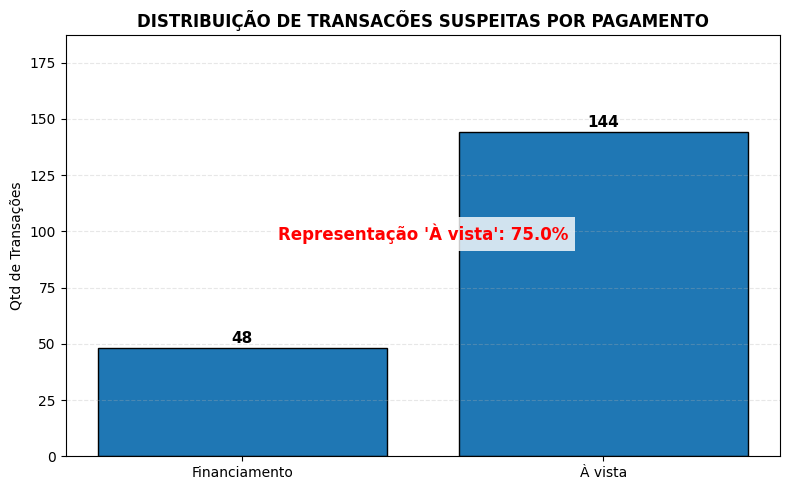

Total Suspeitos: 192
  forma_pagamento  transacao_id
0   Financiamento            48
1         À vista           144


In [192]:

df_profi_suspeito_fpgto = df_master[['transacao_id','forma_pagamento','é suspeito?']]

df_profi_suspeito_fpgto = df_profi_suspeito_fpgto.groupby('é suspeito?')['transacao_id'].count().reset_index()

print(df_profi_suspeito_fpgto)

df_temp = df_master[df_master['é suspeito?'] == 'SIM']

# 2. Agrupamos por 'forma_pagamento' para contar as transações suspeitas
df_plot = df_temp.groupby('forma_pagamento')['transacao_id'].count().reset_index()

# --- CÁLCULO DA PORCENTAGEM ---
total_suspeitas = df_plot['transacao_id'].sum()
# Buscamos o valor de 'À vista' dentro do agrupamento
valor_a_vista = df_plot[df_plot['forma_pagamento'] == 'À vista']['transacao_id'].values[0]
porcentagem = (valor_a_vista / total_suspeitas) * 100
# ------------------------------

# 3. Criando o Gráfico de Barras
plt.figure(figsize=(8, 5))
barras = plt.bar(df_plot['forma_pagamento'], df_plot['transacao_id'], color='#1f77b4', edgecolor='black')

# Adicionando rótulos numéricos sobre as barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. ADICIONANDO O DESTAQUE DA PORCENTAGEM (Conforme sua imagem)
plt.text(0.5, total_suspeitas/2, f"Representação 'À vista': {porcentagem:.1f}%", 
         fontsize=12, color='red', fontweight='bold', ha='center',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=5))

# Customização visual final
plt.title('DISTRIBUIÇÃO DE TRANSACÕES SUSPEITAS POR PAGAMENTO', fontsize=12, fontweight='bold')
plt.ylabel('Qtd de Transações')
plt.ylim(0, max(df_plot['transacao_id']) * 1.3) # Folga no topo
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print para conferência no console
print(f"Total Suspeitos: {total_suspeitas}")
print(df_plot)


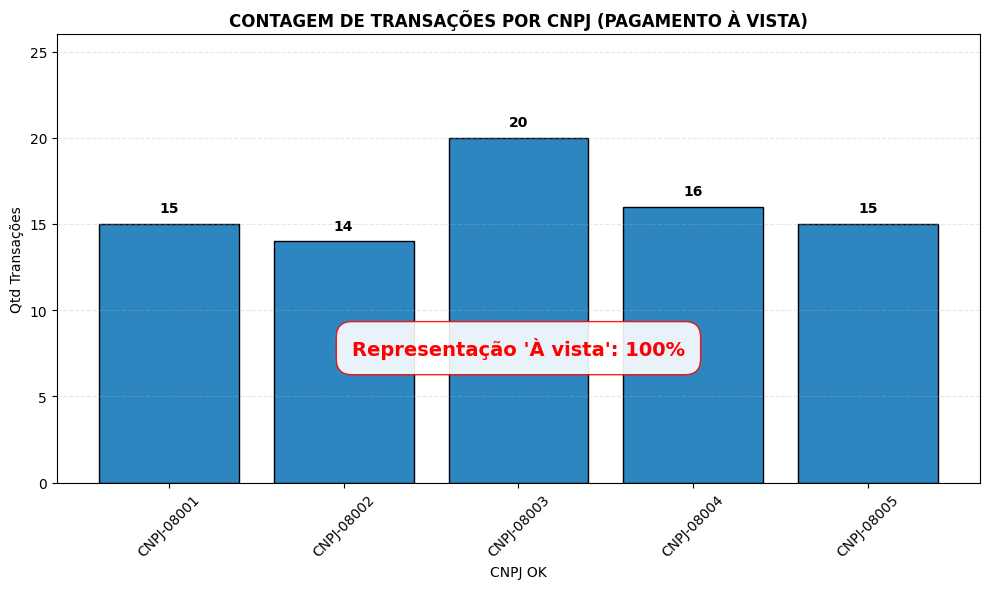

In [209]:

# df_cnpj_suspeito_fpgto = df_master[['transacao_id','forma_pagamento','CNPJ OK']]

# # df_plot = df_temp.groupby('forma_pagamento')['transacao_id'].count().reset_index()

# df_cnpj_suspeito_fpgto = df_cnpj_suspeito_fpgto.groupby('forma_pagamento')[['transacao_id','CNPJ OK']].count().reset_index()

# print(df_cnpj_suspeito_fpgto)

df_cnpj_fpgto = df_master[['transacao_id', 'forma_pagamento', 'CNPJ OK']]
df_cnpj_fpgto = df_cnpj_fpgto[df_cnpj_fpgto['CNPJ OK'].notna()]

# 2. Agrupamento por CNPJ (para ver a contagem de cada um)
# Queremos ver a barra de cada CNPJ no eixo X
df_plot = df_cnpj_fpgto.groupby('CNPJ OK')['transacao_id'].count().reset_index()

# Calculando a métrica para o destaque (À vista / Total)
total_geral = len(df_cnpj_fpgto)
total_a_vista = len(df_cnpj_fpgto[df_cnpj_fpgto['forma_pagamento'] == 'À vista'])
porcentagem = (total_a_vista / total_geral) * 100

# 3. Plotagem
plt.figure(figsize=(10, 6))
# Criando as barras (uma para cada CNPJ)
barras = plt.bar(df_plot['CNPJ OK'].astype(str), df_plot['transacao_id'], color='#2E86C1', edgecolor='black')

# Rótulos de dados (Quantidade em cima de cada barra)
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.5, int(yval), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. DESTAQUE DOS 100% (Estilo caixa de texto centralizada)
# Usamos 'axes fraction' para fixar o texto no meio da área do gráfico
plt.text(0.5, 0.3, f"Representação 'À vista': {porcentagem:.0f}%", 
         fontsize=14, color='red', fontweight='bold', ha='center', va='center',
         transform=plt.gca().transAxes, # Faz o texto ficar fixo no meio do gráfico
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', boxstyle='round,pad=0.8'))

# Customização do Layout
plt.title('CONTAGEM DE TRANSAÇÕES POR CNPJ (PAGAMENTO À VISTA)', fontsize=12, fontweight='bold')
plt.xlabel('CNPJ OK', fontsize=10)
plt.ylabel('Qtd Transações')
plt.xticks(rotation=45) # Rotaciona os CNPJs para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, max(df_plot['transacao_id']) * 1.3)

plt.tight_layout()
plt.show()

In [223]:
df_cpf_cnpj_compras_suspeitas_renda_baixa = df_master[df_master['compra_suspeita?'] == 'SIM']

cpfs_renda_baixa_compra_alta = df_cpf_cnpj_compras_suspeitas_renda_baixa[['comprador_id']]

print(cpfs_renda_baixa_compra_alta)


     comprador_id
18      CPF-01080
58      CPF-05708
62      CPF-03682
76      CPF-06975
79      CPF-05884
...           ...
3354    CPF-06896
3459    CPF-05474
3466    CPF-07219
3504    CPF-01606
3521    CPF-03619

[168 rows x 1 columns]


In [238]:

df_cpf_cnpj_pagos_acima_40 = df_master[df_master['é suspeito?'] == "SIM"]

cpfs_pagos_acima_40 = df_cpf_cnpj_pagos_acima_40[['comprador_id']]
print(cpfs_pagos_acima_40)

print(type(cpfs_pagos_acima_40))


     comprador_id
4       CPF-02381
130     CPF-04460
219     CPF-03599
233     CPF-02222
240     CPF-05748
...           ...
3493    CPF-09014
3495    CPF-09014
3497    CPF-09014
3498    CPF-09014
3501    CPF-09014

[192 rows x 1 columns]
<class 'pandas.DataFrame'>


In [257]:

cnpj_suspeitos = df_master[df_master['CNPJ OK'].notna()]['CNPJ OK'].unique()

cnpj_suspeitos = pd.DataFrame(cnpj_suspeitos, columns=['comprador_id'])

print(type(cnpj_suspeitos))

print(cnpj_suspeitos)

cpf_cnpj_suspeitos_consolidados = pd.concat([cpfs_renda_baixa_compra_alta,cpfs_pagos_acima_40,cnpj_suspeitos],ignore_index=True)
print(cpf_cnpj_suspeitos_consolidados.head(10))

cpf_cnpj_suspeitos_consolidados = cpf_cnpj_suspeitos_consolidados.drop_duplicates()

# # 4. Exportando para CSV
# # Altere o caminho entre aspas para o diretório de sua preferência4

nome_arquivo = 'LISTA_CPFS_CNPJS_SUSPEITOS.csv'
caminho_diretorio = f'C:\MBA_DC_13\projeto_final_programacao_para_DS\projeto_09_lava_imovel\data\\{nome_arquivo}'

cpf_cnpj_suspeitos_consolidados.to_csv(caminho_diretorio, index=False, sep=';', encoding='utf-8-sig')

print(f"Arquivo exportado com sucesso para: {caminho_diretorio}")
print(f"Total de registros únicos: {len(cpf_cnpj_suspeitos_consolidados)}")

<class 'pandas.DataFrame'>
  comprador_id
0   CNPJ-08002
1   CNPJ-08001
2   CNPJ-08005
3   CNPJ-08003
4   CNPJ-08004
  comprador_id
0    CPF-01080
1    CPF-05708
2    CPF-03682
3    CPF-06975
4    CPF-05884
5    CPF-06469
6    CPF-02108
7    CPF-04444
8    CPF-02762
9    CPF-05328
Arquivo exportado com sucesso para: C:\MBA_DC_13\projeto_final_programacao_para_DS\projeto_09_lava_imovel\data\LISTA_CPFS_CNPJS_SUSPEITOS.csv
Total de registros únicos: 175


<>:18: SyntaxWarning: invalid escape sequence '\M'
<>:18: SyntaxWarning: invalid escape sequence '\M'
C:\Users\allyc\AppData\Local\Temp\ipykernel_15668\3217068526.py:18: SyntaxWarning: invalid escape sequence '\M'
  caminho_diretorio = f'C:\MBA_DC_13\projeto_final_programacao_para_DS\projeto_09_lava_imovel\data\\{nome_arquivo}'
